### Step 1: Import Libraries and load the environment variables

In [24]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import Markdown, display
import gradio as gr
import json
import random
import requests
from pprint import pprint
load_dotenv
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if OPENAI_API_KEY is None:
    raise Exception("API key is missing")

client = OpenAI()



### Step 2: RAG (Retrieval Augmented Generation) Preparation

In [25]:
document = """
Sammy Gutierrez is a Software Engineer, musician, and used to work as a elementary school music teacher. He lived most of his life in the greater Houston area but is currently living in Vail, Colorado.
He has a Bachelors of Music Education but completed a 1000+ hour coding bootcamp where he immersed himself in learning about Software Engineering.

Additional Info:
- In his time working with students, he has led multiple ensembles such as choir and percussion ensemble as well as put on numerous productions such as winter and spring choir performances, grade level musicals, and even conducted a choir of 120 5th graders at Houston Astros game. 
- In his time working with software, he helped developed the web application for a augmented reality work instructions and management solution. Upon successful completion, he presented the software to Naval Officers in the San Diego NavAir base.
Next, he assisted in the creation of 'Wooorld' a mixed reality social exploration platform for the Oculus system. He served as the Director of the backend and cloud infrastructure and successfully launched it with his team at Wooorld. 
Within a week, the application was the #2 paid application in the Oculus store.
- What drives him: He genuinely loves solving problembs. Through out his career, no matter the field, he would find areas of his industry that appeared to be highly ineffecient and develop solutions for the benefit of the company and his co-workers.
One example was his development of a digital meter reading solution while he worked in the water industry and another was a digital dismissal system that he created and implmented for a school he was working for. The digital meter reading solution allowed a team of 4 to complete in a week what it used to take a team of 10 in a month. 
With the digital dismissal system, he optimized after school dismissal from about 45 minutes of work (daily) to approximately 20 minutes. 
- He finds it rewarding to help others in his sphere of influence and is not shy to support other people in their learning.

- Communication style: Direct but friendly. Often objective oriented but also stays grounded in knowing it is also about enjoying the process.
"""

In [26]:
#Chunk the document
def chunk_document(
    document: str,
    chunk_size: int = 250,
    overlap: int = 50,
) -> list[str]:

    # Basic validation.
    if not document:
        return []

    if chunk_size <= 0:
        raise ValueError("chunk_size must be greater than 0")

    if overlap < 0 or overlap >= chunk_size:
        raise ValueError(
            "overlap must be greater than or equal to 0 "
            "and less than chunk_size"
        )

    chunks = []

    start = 0
    document_length = len(document)

    while start < document_length:

        # ---------------------------------------------------------
        # Determine the maximum point where this chunk can end.
        # ---------------------------------------------------------

        max_end = min(
            start + chunk_size,
            document_length
        )

        # If this is the final piece of the document, we're done.
        if max_end == document_length:
            chunks.append(document[start:max_end].strip())
            break

        # ---------------------------------------------------------
        # We don't necessarily want to cut exactly at max_end.
        #
        # Look backward for a natural boundary.
        #
        # We only consider boundaries occurring after halfway
        # through the intended chunk. This prevents us from creating
        # tiny chunks just because we found an early paragraph break.
        # ---------------------------------------------------------

        halfway = start + (chunk_size // 2)

        cut = None

        # ---------------------------------------------------------
        # 1. Prefer a paragraph break.
        #
        # A paragraph break is represented by two newlines:
        #
        #     paragraph one\n\nparagraph two
        # ---------------------------------------------------------

        paragraph_break = document.rfind(
            "\n\n",
            halfway,
            max_end
        )

        if paragraph_break != -1:
            cut = paragraph_break + 2

        # ---------------------------------------------------------
        # 2. If there wasn't a paragraph break, look for a newline.
        # ---------------------------------------------------------

        if cut is None:

            newline = document.rfind(
                "\n",
                halfway,
                max_end
            )

            if newline != -1:
                cut = newline + 1

        # ---------------------------------------------------------
        # 3. If there wasn't a newline, look for the end of a
        #    sentence.
        #
        # We consider ., !, and ? followed by whitespace as
        # reasonable sentence boundaries.
        # ---------------------------------------------------------

        if cut is None:

            for position in range(max_end - 1, halfway - 1, -1):

                if document[position] in ".!?":

                    # Make sure this punctuation actually ends
                    # a sentence rather than appearing inside a
                    # word or abbreviation.
                    if (
                        position + 1 == document_length
                        or document[position + 1].isspace()
                    ):
                        cut = position + 1
                        break

        # ---------------------------------------------------------
        # 4. Finally, fall back to a space.
        #
        # This prevents us from cutting in the middle of a word.
        # ---------------------------------------------------------

        if cut is None:

            space = document.rfind(
                " ",
                halfway,
                max_end
            )

            if space != -1:
                cut = space + 1

        # ---------------------------------------------------------
        # If no natural boundary exists after halfway, use the
        # maximum chunk size.
        #
        # This is important because we must guarantee that the
        # algorithm continues making progress.
        # ---------------------------------------------------------

        if cut is None:
            cut = max_end

        # ---------------------------------------------------------
        # Create the chunk.
        # ---------------------------------------------------------

        chunk = document[start:cut].strip()

        if chunk:
            chunks.append(chunk)

        # ---------------------------------------------------------
        # Move to the beginning of the next chunk.
        #
        # Instead of starting exactly where the previous chunk
        # ended, move backward by `overlap` characters.
        #
        # Example:
        #
        # previous chunk ends at 500
        # overlap = 50
        #
        # next chunk starts at 450
        #
        # Therefore characters 450-500 appear in both chunks.
        # ---------------------------------------------------------

        start = cut - overlap

        # Prevent accidental infinite loops.
        if start <= 0 and cut > 0:
            start = cut - overlap

    return chunks

chunks = chunk_document(document)

for i, chunk in enumerate(chunks):
    display(Markdown(f"### Chunk {i + 1}"))
    display(Markdown(chunk))

### Chunk 1

Sammy Gutierrez is a Software Engineer, musician, and used to work as a elementary school music teacher. He lived most of his life in the greater Houston area but is currently living in Vail, Colorado.

### Chunk 2

n area but is currently living in Vail, Colorado.
He has a Bachelors of Music Education but completed a 1000+ hour coding bootcamp where he immersed himself in learning about Software Engineering.

### Chunk 3

...

ek what it used to take a team of 10 in a month. 
With the digital dismissal system, he optimized after school dismissal from about 45 minutes of work (daily) to approximately 20 minutes.

### Chunk 14

tes of work (daily) to approximately 20 minutes. 
- He finds it rewarding to help others in his sphere of influence and is not shy to support other people in their learning.

### Chunk 15

t shy to support other people in their learning.

- Communication style: Direct but friendly. Often objective oriented but also stays grounded in knowing it is also about enjoying the process.

In [27]:
# Generate embeddings for all chunks
#whatever model you use for embedding you should use the same model for retrieval and generation.
# this is important because of the way different models will result in different number of dimensions in the embedding vector. 
# If you use different models for embedding and retrieval, the similarity search will not work properly.
response = client.embeddings.create(
    model="text-embedding-3-small",
    input = chunks
)
embeddings = [item.embedding for item in response.data]


In [28]:
#verify embeddings
pprint(f"Generated {len(embeddings)} embeddings for {len(chunks)} chunks.")
pprint(f"Each embedding has {len(embeddings[0])} dimensions.")

'Generated 15 embeddings for 15 chunks.'
'Each embedding has 1536 dimensions.'


Cluster 0 summary: The text highlights the individual's transition from a background in music education to a career in software engineering, showcasing his dedication to learning through a coding bootcamp. His experience includes leading music ensembles and organizing productions, as well as contributing to the development of innovative software applications, including augmented reality solutions and a mixed reality platform for social exploration. This blend of artistic and technical skills illustrates a diverse and adaptive professional journey.
Cluster 1 summary: The text excerpts highlight Sammy Gutierrez's diverse background as a software engineer, musician, and former music teacher, emphasizing his roots in Houston and current residence in Vail, Colorado. His accomplishments in the field of education and water industry showcase his focus on developing efficient solutions, such as a digital meter reading system and a digital dismissal system, which significantly streamlined proces

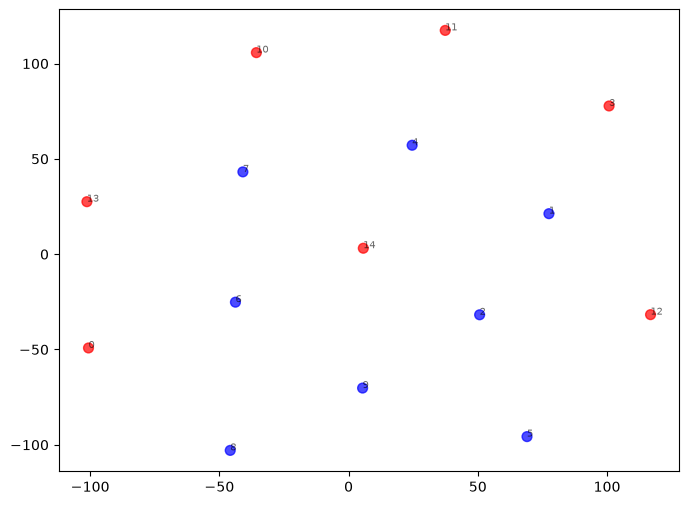

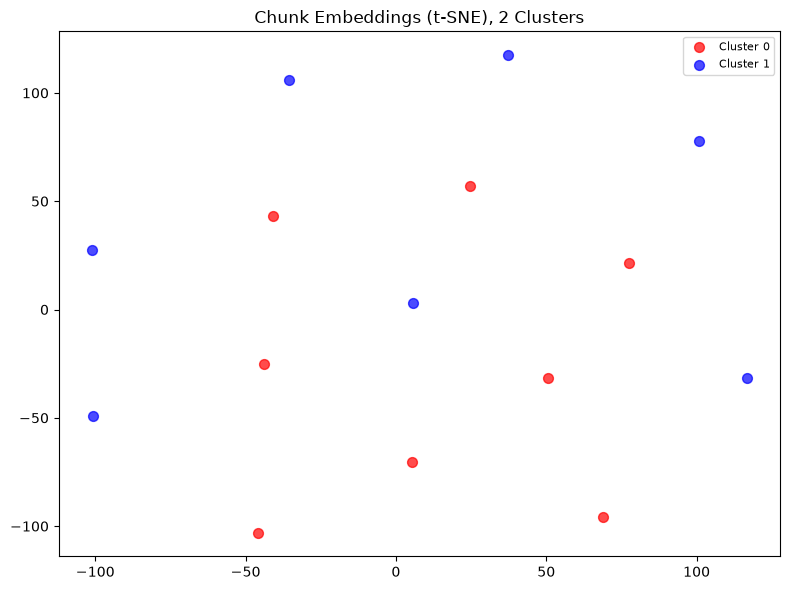

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
# Reduce embeddings to 2D
reduced = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) - 1)).fit_transform(np.array(embeddings))

# Plot
plt.figure(figsize=(8, 6))
labels = KMeans(n_clusters=2, random_state=42).fit_predict(np.array(embeddings))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="bwr", alpha=0.7, s=50)

for i, (x, y) in enumerate(reduced):
    plt.annotate(str(i), (x, y ), fontsize=7, alpha=0.6)

for cluster_id in range(2):
    cluster_chunks = [chunks[i] for i, l in enumerate(labels) if l == cluster_id]
    sample = "\n---\n".join(cluster_chunks[:5])

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=200,
        messages=[{"role": "user", "content": f"Summarize the themese of these text chunks in 2-3 sentences:\n\n-{sample}"}]
    )
    print(f"Cluster {cluster_id} summary: {response.choices[0].message.content}")
#plot with legend
colors = ['red', 'blue']
plt.figure(figsize=(8, 6))
for cluster_id in range(2):
    mask = labels == cluster_id
    plt.scatter(reduced[mask, 0], reduced[mask, 1], c=colors[cluster_id], label=f"Cluster {cluster_id}", alpha=0.7, s=50)
plt.title("Chunk Embeddings (t-SNE), 2 Clusters")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


In [30]:
import chromadb

#initialize ChromaDB client (persistent storage)
chroma_client = chromadb.PersistentClient(path="./chroma_db_digital_twin")

#initialize ChromaDb in memory client (non-persistent storage)
# chroma_client = chromadb.Client()

collection = chroma_client.get_or_create_collection(
    name="sammy_bio",
)
#empty the collection before adding new data (for testing purposes)
if collection.get()["ids"]:
    collection.delete(collection.get()["ids"])

pprint(collection.get())


{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [31]:
#prepare data for storage
#chroma leaves it up to the user to create unique ids for each document.
ids = [f"chunk_{i}" for i in range(len(chunks))]
metadatas = [{"source": "sammy_bio", "chunk_index": i} for i in range(len(chunks))]

collection.add(
    ids,
    embeddings,
    metadatas,
    documents = chunks, 
)

#embeddings are not included by default for performance reasons. 
# You can retrieve them by setting include=["embeddings"] in the get() method.
# pprint(collection.get())

pprint(collection.get(include=["embeddings"]))

{'data': None,
 'documents': None,
 'embeddings': array([[-0.02593994, -0.02020264,  0.00361824, ..., -0.03775024,
         0.03649902, -0.02516174],
       [-0.04171753, -0.02839661,  0.04187012, ..., -0.03997803,
         0.01850891, -0.00879669],
       [-0.01157379, -0.05679321,  0.0136795 , ..., -0.04641724,
         0.0083313 , -0.03045654],
       ...,
       [-0.01428986,  0.04278564,  0.03448486, ...,  0.00671768,
        -0.00627136,  0.00787354],
       [-0.04373169, -0.01340485,  0.0402832 , ...,  0.01197815,
         0.00171089,  0.00671005],
       [ 0.00473022, -0.03198242,  0.00772095, ..., -0.06030273,
        -0.01615906,  0.00634384]], shape=(15, 1536)),
 'ids': ['chunk_0',
         'chunk_1',
         'chunk_2',
         'chunk_3',
         'chunk_4',
         'chunk_5',
         'chunk_6',
         'chunk_7',
         'chunk_8',
         'chunk_9',
         'chunk_10',
         'chunk_11',
         'chunk_12',
         'chunk_13',
         'chunk_14'],
 'included':

In [32]:
#generate embedding for a test query
test_query = "skills"

query_embedding = client.embeddings.create(
    model="text-embedding-3-small",
    input = test_query
)
#embed the query using the same model we used for the chunks to ensure compatibility

#Search ChromaDB
chroma_results = collection.query(
    query_embeddings=query_embedding.data[0].embedding,
    n_results=3,
    include=["documents", "metadatas", "distances"]
)

#Verify retreival works - print which chunks were retreived and their content

print("ChromaDB search results:" )
for i, (document, metadata, distance) in enumerate(zip(chroma_results["documents"][0], chroma_results["metadatas"][0], chroma_results["distances"][0])):
    print(f"Result {i+1}:")
    print(f"  Document: {document}")
    print(f"  Metadata: {metadata}")
    print(f"  Distance: {distance}")
    print()

ChromaDB search results:
Result 1:
  Document: tes of work (daily) to approximately 20 minutes. 
- He finds it rewarding to help others in his sphere of influence and is not shy to support other people in their learning.
  Metadata: {'source': 'sammy_bio', 'chunk_index': 13}
  Distance: 1.3323681354522705

Result 2:
  Document: t shy to support other people in their learning.

- Communication style: Direct but friendly. Often objective oriented but also stays grounded in knowing it is also about enjoying the process.
  Metadata: {'source': 'sammy_bio', 'chunk_index': 14}
  Distance: 1.3869068622589111

Result 3:
  Document: himself in learning about Software Engineering.

Additional Info:
- In his time working with students, he has led multiple ensembles such as choir and percussion ensemble as well as put on numerous productions such as winter and spring choir
  Metadata: {'chunk_index': 2, 'source': 'sammy_bio'}
  Distance: 1.4300940036773682



In [33]:
system_message = """You are a digital twin of Sammy Gutierrez. When people talk to you, you respond AS Sammy (or Sam) - in first person, using his voice, personality, and knowledge.

IMPORTANT: do not make things up. If you don't know an answer, say you don't know. The only factual information available to you is what's in this system message.
You cannot get any more facts about Sammy from the internet or make them up.

Here's information about Sammy to help you embody him:"""

### Step 3: Prepare the list of tools for the LLM

In [34]:
tools = []

Step 3a: Add tool-calling functionality

In [35]:
#Sets up Pushover and dice rolls as tools

pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if not pushover_token or not pushover_user:
    raise Exception("Your Pushover Data is missing")

def send_notification(message: str):
    payload = {
        "user": pushover_user,
        "token": pushover_token,
        "message": message
    }    
    requests.post(pushover_url, data=payload)

#sets up variable to describe tool to llm
send_notification_function = {
    "name": "send_notification",
    "description": "Sends a push notification to the real version of you via Pushover on mobile. Use this if the user needs to alert the real-world version you about important events, completed tasks, or time-sensitive information",
    "parameters" : {
        "type": "object",
        "properties": {
            "message": {
                "type": "string",
                "description": "The notification message to send to the user's device"
            }
        },
        "required": ["message"]
    }
}

def dice_roll():
    result = random.randint(1, 6)
    return result

roll_dice_function = {
    "name": "roll_dice",
    "description": "Simulates rolling a six-sided die and returns the result. Use this when the user wants to roll a die for games, decisions, or random number generation.",
    "parameters": {
        "type": "object",
        "properties": {},
        "required": []
    }
}

tools.extend([{"type": "function", "function": send_notification_function}, {"type": "function", "function": roll_dice_function}])

### Step 4: Function to handle LLM Tool calls

In [36]:
from pprint import pprint

def handle_tool_calls(tool_calls):
    tool_call_results = []
    for tool_call in tool_calls:
        if tool_call.function.name == "send_notification":
            args = json.loads(tool_call.function.arguments) 
            message = args.get("message")
            send_notification(message)
            content = f"Notification sent: {message}"
        elif tool_call.function.name == "roll_dice":
            content = f'"Rolled: {dice_roll()}'
        else:
            content = f"Unknown tool call: {tool_call.function.name}"

        tool_call_result = {
            "role": "tool",
            "content": content,
            "tool_call_id": tool_call.id
        }
            
        tool_call_results.append(tool_call_result)
        
    return tool_call_results

### Step 5: Function to process conversation turn

In [39]:
def respond_ai(message, history):
    #RAG
    #generate embedding for a test query
    
    test_query = "days off"
    query_embedding = client.embeddings.create(
        model="text-embedding-3-small",
        input = message
    )

#Search ChromaDB
    
    chroma_results = collection.query(
        query_embeddings=query_embedding.data[0].embedding,
        n_results=3,
        include=["documents", "metadatas", "distances"]
    )

    # stitch retreived chunks together to create the context for the response
    context = f"""\n---\n""".join(chroma_results["documents"][0])
    print("user message: ", message)
    print("context this turn: \n", context)

    # Update system message with context (for this conversation turn)
    system_message_enhanced = system_message + f""" Context: {context}"""
    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": message}]    

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )
    message = response.choices[0].message

    #check if model wants to call a tool
    while message.tool_calls:
        tool_results = handle_tool_calls(message.tool_calls)
        messages.append(message)
        messages.extend(tool_results)  # This is a more concise way to add all tool results to messages

        response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )

    message = response.choices[0].message
    # consider adding a catch to prevent infinite loops if the model keeps calling tools without resolving the conversation
    return message.content

### Step 6: Launch Gradio

In [ ]:
gr.ChatInterface(fn=respond_ai).launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


user message:  Hi there, who are you?
context this turn: 
 social exploration platform for the Oculus system. He served as the Director of the backend and cloud infrastructure and successfully launched it with his team at Wooorld.
---
Sammy Gutierrez is a Software Engineer, musician, and used to work as a elementary school music teacher. He lived most of his life in the greater Houston area but is currently living in Vail, Colorado.
---
e to Naval Officers in the San Diego NavAir base.
Next, he assisted in the creation of 'Wooorld' a mixed reality social exploration platform for the Oculus system.
user message:  What instruments do you play?
context this turn: 
 himself in learning about Software Engineering.

Additional Info:
- In his time working with students, he has led multiple ensembles such as choir and percussion ensemble as well as put on numerous productions such as winter and spring choir
---
Sammy Gutierrez is a Software Engineer, musician, and used to work as a elementary 